# Acquisition notebook

This notebook is split between:
- **run cells** here
- reusable helpers in the `utils/` Python files next to the notebook

The goal is to keep this notebook readable and focused on experiments.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import serial
import pyvisa as pv

In [2]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

from datetime import datetime
from pathlib import Path

In [3]:
from utils.oc3 import OC3
from utils.pm100a import record_pm100a

from utils.temperature import generate_temperature_list

In [4]:
DATA_DIR = "data/data_temp_SHG"
os.makedirs(DATA_DIR, exist_ok=True)

In [5]:
wavelength = 780e-6 # wavelength in microns!

In [6]:
# Check available VISA resources
rm = pv.ResourceManager()
print(rm.list_resources())

('USB0::0x1313::0x8079::P1007388::INSTR', 'ASRL1::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR')


In [7]:
# Connect to PM100A power meter via PyVISA
pm100a = rm.open_resource('USB0::0x1313::0x8079::P1007388::INSTR')
print(pm100a.query('*IDN?'))

Thorlabs,PM100A,P1007388,2.5.0



## Temperature sweep with PM100A + OC3

This run:
- connects the PM100A for power reading
- uses the OC3 for temperature control
- waits for stabilization
- optionally asks for manual lock confirmation
- reads one or several PM100A values per temperature
- saves one CSV per temperature and one summary CSV

In [7]:
# FOLDER
TEMP_SCAN_DIR = os.path.join(DATA_DIR, "temperature_scan")
RUN_NAME = time.strftime("temp_scan %m %d")
RUN_DIR = os.path.join(DATA_DIR, RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)

print("Temperature scan data will be saved in:", RUN_DIR)

Temperature scan data will be saved in: data/data_temp_SHG\temp_scan 05 05


In [9]:
raw = pm100a.query("READ?").strip()

In [8]:
# Connect to OC3 temperature controller via pyserial
OC_PORT = "COM3" 
oc3 = OC3(port=OC_PORT)
print("Connected to OC3 on port", OC_PORT, oc3.status())

Connected to OC3 on port COM3 b'j5544.850;44.283;1;07.0;0;0;0;24.070;c24/1.54p;0;0;44.850;73'


In [11]:
ASK_USER_CONFIRMATION = False

# TEMPERATURE CONTROL
TEMP_START = 43.5
TEMP_END = 46.5
TEMP_STEP = 0.05
RAMP_RATE = 0.02

TEMP_TOL = 0.01
STABLE_TIME = 30.0
POLL_INTERVAL = 1.0

# POWER-METER
PM_SAMPLES_PER_POINT = 20
PM_SAMPLE_DELAY = 0.1

PM_RECORD_DURATION = 1          # seconds
PM_SAMPLE_DELAY = 0.1          # seconds between reads
PM_USE_FETCH = False           # False -> READ?, True -> FETCh?
PM_AVERAGE_COUNT = 1           # instrument-side averaging

INFO:1:2026_05_05__08_48_24__temperature_scan


Temperature list: [43.5, 43.55, 43.6, 43.65, 43.7, 43.75, 43.8, 43.85, 43.9, 43.95, 44.0, 44.05, 44.1, 44.15, 44.2, 44.25, 44.3, 44.35, 44.4, 44.45, 44.5, 44.55, 44.6, 44.65, 44.7, 44.75, 44.8, 44.85, 44.9, 44.95, 45.0, 45.05, 45.1, 45.15, 45.2, 45.25, 45.3, 45.35, 45.4, 45.45, 45.5, 45.55, 45.6, 45.65, 45.7, 45.75, 45.8, 45.85, 45.9, 45.95, 46.0, 46.05, 46.1, 46.15, 46.2, 46.25, 46.3, 46.35, 46.4, 46.45, 46.5]

Point 1/61  |  Set temperature = 43.500 °C
Current T: 44.608  ± 0.047 °C
Mean power = 0.402041 ± 0.004851 mW

Point 2/61  |  Set temperature = 43.550 °C
Current T: 43.602  ± 0.031 °C
Mean power = 0.068052 ± 0.007427 mW

Point 3/61  |  Set temperature = 43.600 °C
Current T: 43.502  ± 0.001 °C
Mean power = 0.134376 ± 0.006685 mW

Point 4/61  |  Set temperature = 43.650 °C
Current T: 43.514  ± 0.001 °C
Mean power = 0.120164 ± 0.005364 mW

Point 5/61  |  Set temperature = 43.700 °C
Current T: 43.563  ± 0.002 °C
Mean power = 0.089075 ± 0.004712 mW

Point 6/61  |  Set temperature = 4

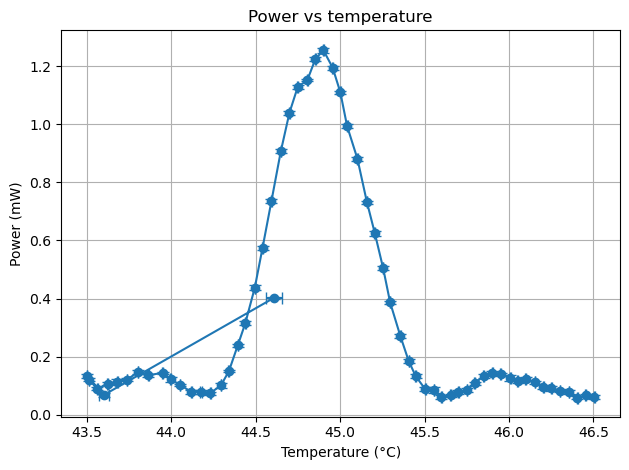

In [13]:
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell("temperature_scan")

temps = generate_temperature_list(TEMP_START, TEMP_END, TEMP_STEP)
scan_results = []

PM_RECORD_DURATION = 5      # seconds
oc3.enable()

print("Temperature list:", temps)
list_SHG_powers , list_SHG_errors = [] , []
list_Tmeas , list_Terrors = [] , []
for i, T in enumerate(temps, start=1):
    print("\n" + "=" * 60)
    print(f"Point {i}/{len(temps)}  |  Set temperature = {T:.3f} °C")
    print("=" * 60)

    oc3.set_temperature(T, ramp=RAMP_RATE)
    time.sleep(10)

    Tmeas, Terror = oc3.get_mean_temperature(duration_s=4.0)
    print(f"Current T: {Tmeas:.3f}  ± {Terror:.3f} °C")

    mean_mW, error_mW = record_pm100a(
        pm100a,
        duration_s=2,
        dt_s=PM_SAMPLE_DELAY
    )
    list_SHG_powers.append(mean_mW)
    list_SHG_errors.append(error_mW)
    list_Tmeas.append(Tmeas)
    list_Terrors.append(Terror)
    print(f"Mean power = {mean_mW:.6f} ± {error_mW:.6f} mW")



oc3.set_temperature(temps[0], ramp=RAMP_RATE)
time.sleep(5)
plt.errorbar(list_Tmeas, list_SHG_powers, xerr = list_Terrors, yerr = list_SHG_errors , fmt="o-", capsize=4)
plt.xlabel("Temperature (°C)")
plt.ylabel("Power (mW)")
plt.title("Power vs temperature")
plt.grid(True)
plt.tight_layout()
plt.show()


aqm.save_acquisition(list_Tmeas=list_Tmeas, list_SHG_powers=list_SHG_powers, list_SHG_errors=list_SHG_errors, list_Terrors=list_Terrors , pump_power_mW = 300)

In [ ]:
print(RUN_DIR)
aqm = AcquisitionAnalysisManager(RUN_DIR)
data_name = "temperature_scan_summary"
print(data_name)
aqm.acquisition_cell(data_name)

df_scan = pd.DataFrame(scan_results)
aqm.save_acquisition(
    acquisition_type="scan_status",
    status="interrupted",
    scan=scan_results,
)

INFO:1:2026_04_28__16_51_36__temperature_scan_summary


data/data_temp_SHG/temp_scan 04 28
temperature_scan_summary


## Single pass test

We set the right temperature on the OC3, and test different waist values. We simply record the average over time on the power-meter.

In [9]:
# FOLDER
TEMP_SCAN_DIR = os.path.join(DATA_DIR, "waist_scan")
RUN_NAME = time.strftime("waist_scan %m %d")
RUN_DIR = os.path.join(DATA_DIR, RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)

print("Waist scan data will be saved in:", RUN_DIR)

Waist scan data will be saved in: data/data_temp_SHG\waist_scan 05 05


In [19]:
# Check OC3 status
Tmeas, Terror = oc3.get_mean_temperature(duration_s=4.0)
print(f"Current T: {Tmeas:.3f}  ± {Terror:.3f} °C")

Current T: 44.850  ± 0.001 °C


In [ ]:
# Get current power reading
raw = pm100a.query("READ?").strip()
print("Current power reading (raw):", raw)

# Set input power
Pin = 
focal_length_mm = 100.0
waist_um = 

# Set scan parameters
duration_s = 10

Current power reading (raw): 1.11528760E-04


In [ ]:
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell("waist_scan")

mean_mW, error_mW = record_pm100a(
        pm100a,
        duration_s=duration_s,
        dt_s=0.1
    )

print(f"Mean power = {mean_mW:.6f} ± {error_mW:.6f} mW")

# Save acquisition data ()
aqm.save_acquisition(Pin=Pin, focal_length_mm=focal_length_mm, waist_um=waist_um, mean_mW=mean_mW, error_mW=error_mW, Tmeas=Tmeas, Terror=Terror)

INFO:1:2026_05_05__15_15_47__waist_scan


Mean power = 0.106894 ± 0.001476 mW
